# Dice Score Dataset Inspector
Load and visualize dice images from the dice_score dataset using an iterator.

## 1. Import Required Libraries

In [1]:
import sys
sys.path.insert(0, '/workspace/ai')

import numpy as np
import matplotlib.pyplot as plt
from src.dataset import S7DatasetDiceScore, get_dice_crops
from src.config.config import load_config

print("Libraries imported successfully!")

2026-04-07 07:55:31.166833: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 07:55:31.178793: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-07 07:55:31.192113: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-07 07:55:31.196400: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-07 07:55:31.207603: I tensorflow/core/platform/cpu_feature_guar

Libraries imported successfully!


## 2. Load the Dice Score Dataset

In [2]:
# Load config
config = load_config('config/config.yml')

# Get all dice crops
print("Loading dataset...")
all_dice_crops = get_dice_crops(
    dataset_path=config.dataset_path,
    num_workers=config.num_workers,
)
print(f"Total dice crops: {len(all_dice_crops)}")

# Create dataset instance
dataset = S7DatasetDiceScore(
    dice_crops=all_dice_crops,
    image_resolution=config.tasks.dice_score.image_resolution,
    cache_path="output/dice-score-train",
    colored=config.colored,
    use_random=True,
    dataset_repeat=1,
)

print("Dataset loaded successfully!")

Loading dataset...
Total dice crops: 1386
Dataset loaded successfully!


## 3. Create a Dataset Iterator

In [3]:
# Create an iterator from the dataset
dataset_iterator = iter(dataset.generate_data())

print("Iterator created successfully!")
print("Use next(dataset_iterator) to get the next image-label pair")

Iterator created successfully!
Use next(dataset_iterator) to get the next image-label pair


## 4. Visualize Images with Next
Run this cell multiple times to see different images from the dataset

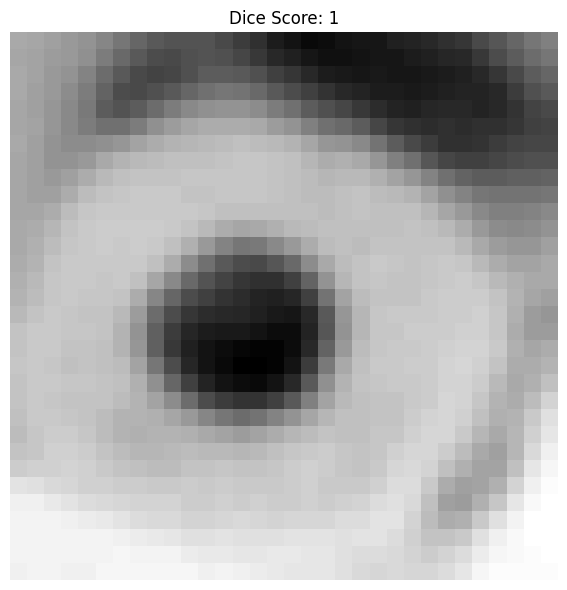

Image shape: (32, 32, 1)
Dice score label: 1 (index: 0)
Image dtype: uint8
Image min: 24, max: 104


In [273]:
# Get next image and label from iterator
img, label = next(dataset_iterator)

# Create figure and display the image
fig, ax = plt.subplots(figsize=(6, 6))

# Display the image (handle both grayscale and color)
if len(img.shape) == 2:
    # Grayscale image
    ax.imshow(img, cmap='gray')
elif img.shape[2] == 1:
    # Single channel image
    ax.imshow(img[:,:,0], cmap='gray')
else:
    # Color image
    ax.imshow(img.astype(np.uint8))

ax.set_title(f'Dice Score: {label + 1}')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {img.shape}")
print(f"Dice score label: {label + 1} (index: {label})")
print(f"Image dtype: {img.dtype}")
print(f"Image min: {img.min()}, max: {img.max()}")